# Comparison to ground truth

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba, LinearSegmentedColormap, ListedColormap
from IPython.display import display
from ipywidgets import Dropdown, interactive, Layout

plt.rcParams['figure.dpi'] = 150

In [2]:
folder_data = './data/'
gt = np.load(folder_data + 'ground_truth.npy')
phase_maps = np.load(folder_data + 'phase_maps_gt.npy')
diffs = np.load(folder_data + 'diffs.npy')

In [3]:
phase_names = ['tp_001', 'tp_100-1', 'tp_100-2', 't1-1', 't1-2']
colors = ('cornflowerblue', 'orange', 'salmon', 'seagreen', 'darkseagreen')
colors_rgba = [to_rgba(c) for c in colors]

names_gt = ['Al', r'$\theta^{\prime}_{100}$', r'$\theta^{\prime}_{001}$', 'T$_1$']
color_names_gt = ['linen', 'darkorange', 'dodgerblue', 'forestgreen']
colors_gt = [to_rgba(c) for c in color_names_gt]
cmap_gt = LinearSegmentedColormap.from_list('gt_cmap', colors_gt, N=len(color_names_gt))

diff_cmap = ListedColormap(['white', 'black'])

interactive(children=(Dropdown(description='Templates:', index=2, layout=Layout(width='250px'), options=('A: s…

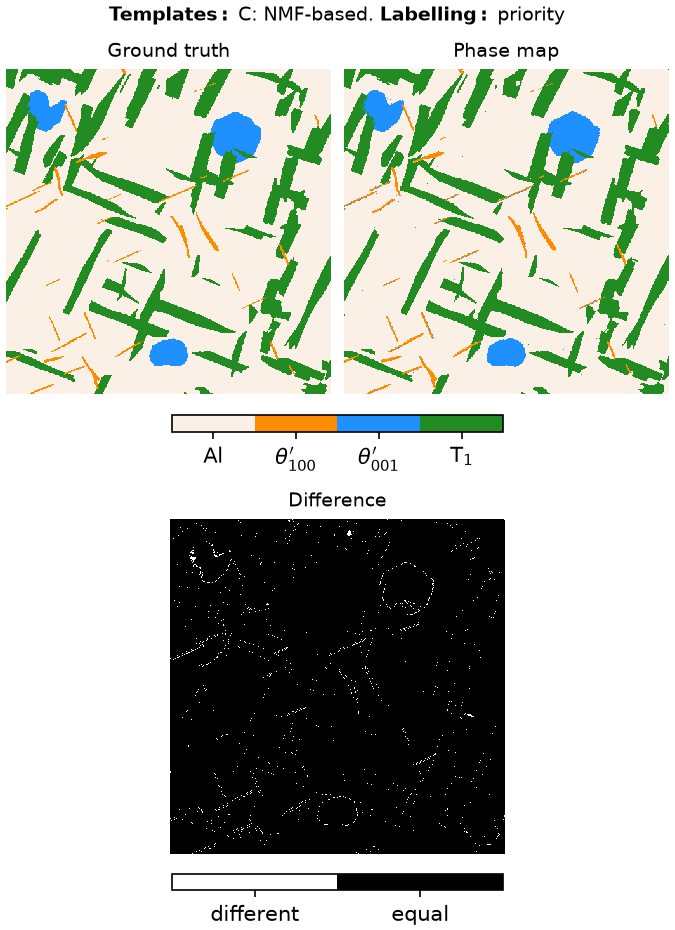

In [4]:
# | label: app:ground_truth_comparison_widget
fig = plt.figure(layout='constrained', figsize=(4.5, 6.2))

subfigs = fig.subfigures(2, 1, wspace=0.0, height_ratios=[1, 1])
ax = subfigs[0].subplots(1, 2)
ax[0].axis('off')
gt_ax = ax[0].imshow(gt, cmap=cmap_gt, interpolation='none')
ax[0].set_title('Ground truth', fontsize=9)
ax[1].axis('off')
phase_map_ax = ax[1].imshow(phase_maps[0], cmap=cmap_gt, interpolation='none')
ax[1].set_title('Phase map', fontsize=9)
cbar = subfigs[0].colorbar(gt_ax, shrink=0.5, ax=ax, location='bottom')
yticks = [0.5, 1.5, 2.5, 3.5]
cbar.set_ticks(yticks, labels=names_gt)

axd = subfigs[1].subplots(1, 1)
axd.axis('off')
diff_ax = axd.imshow(diffs[0], cmap=diff_cmap, interpolation='none')
axd.set_title('Difference', fontsize=9)
cbar_ = subfigs[1].colorbar(diff_ax, shrink=0.5, ax=axd, location='bottom')
yticks_diff = [0.25, 0.75]
cbar_.set_ticks(yticks_diff, labels=['different', 'equal'])
cbar_.ax.tick_params(color='black', labelcolor='black')

fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True
fig.canvas.toolbar_position = 'top'

i, ii, j = 0, 2, 1
templates = ['A: simulated', 'B: selected', 'C: NMF-based']
labelling = ['max NCC', 'priority']

fig.suptitle(r'$\bf{Templates:}$ ' + templates[ii] + '. ' + r'$\bf{Labelling:}$ ' + labelling[j], fontsize=9)

def update_plots(tw, lw):
    if tw[0] == 'A':
        i, ii = 4, 0
    elif tw[0] == 'B':
        i, ii = 2, 1
    elif tw[0] == 'C':
        i, ii = 0, 2
    if lw[0] == 'm':
        j = 0
    elif lw[0] == 'p':
        j = 1
    fig.suptitle(r'$\bf{Templates:}$ ' + templates[ii] + '. ' + r'$\bf{Labelling:}$ ' + labelling[j], fontsize=9)
    phase_map_ax.set_data(phase_maps[i+j])
    diff_ax.set_data(diffs[i+j])
    fig.canvas.draw_idle()
    return None

template_widget = Dropdown(options=templates, index=2, description='Templates:', 
                           layout=Layout(width='250px'), style={'description_width': '100px'}, disabled=False)
labelling_widget = Dropdown(options=labelling, index=1, description='Phase labelling: ', 
                            layout=Layout(width='250px'), style={'description_width': '100px'}, disabled=False)
wid = interactive(update_plots, tw=template_widget, lw=labelling_widget)
display(wid)